# Data Cleaning

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [9]:
data=pd.read_csv('data/StudentsPerformance.csv')

In [10]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Replacing some high school with high school and some college with college in parental level of education column

In [12]:
data['parental level of education'] = (
    data['parental level of education']
    .replace({
        'some high school': 'high school',
        'some college': 'college'
    })
)
data['parental level of education'].unique()

array(["bachelor's degree", 'college', "master's degree",
       "associate's degree", 'high school'], dtype=object)

In [13]:
data['parental level of education'].rename('parents education')

0       bachelor's degree
1                 college
2         master's degree
3      associate's degree
4                 college
              ...        
995       master's degree
996           high school
997           high school
998               college
999               college
Name: parents education, Length: 1000, dtype: object

### Encoding the Lunch and Test Preparation Course Column with 0/1

In [14]:
data['lunch']=(data['lunch'].replace({
        'standard':1,
        'free/reduced':0
    })
)

data['test preparation course']=(data['test preparation course'].replace({
        'completed':1,
        'none':0
    })
)

### Adding Total Score and Avg Score Column in dataset

In [15]:
data['total score']=data['math score'] + data['reading score'] + data['writing score']
data['average']=data['total score']/3

### HistoGram on Total Score and Average Score

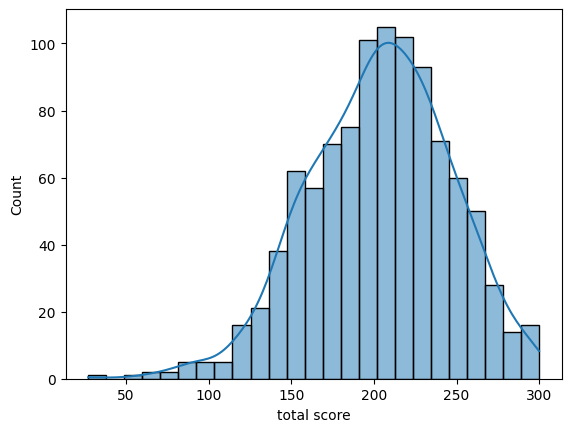

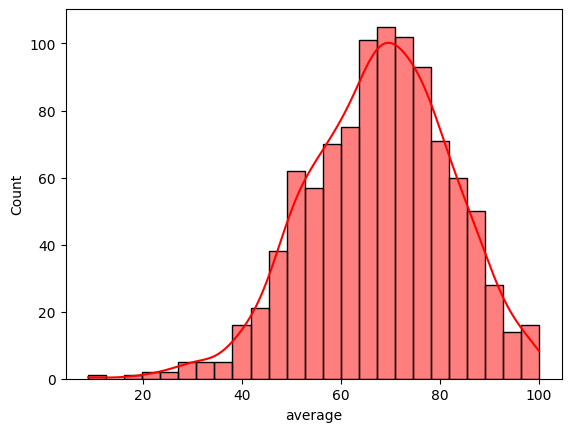

In [25]:
sns.histplot(data['total score'], bins=25, kde=True)
plt.show()
sns.histplot(data['average'], bins=25, color='red',kde=True)
plt.show()